In [1]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score,davies_bouldin_score
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
data = pd.read_csv('dummy_lyrics_features.csv')
data.head()

,track_id,artist,genre,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3
0,Pop_001,PopArtist_1,Pop,0.474836,6.861736,0.729538,87.615149,-0.117077,-0.117068,0.789606
1,Pop_002,PopArtist_1,Pop,0.488372,6.530526,0.708512,77.682912,-0.232865,0.120981,-0.956640
2,Pop_003,PopArtist_1,Pop,0.363754,6.437712,0.397434,81.571237,-0.454012,-0.706152,0.732824
3,Pop_004,PopArtist_1,Pop,0.438711,7.067528,0.315050,77.278086,0.055461,-0.575497,0.187849
4,Pop_005,PopArtist_1,Pop,0.419968,6.708306,0.479659,89.261391,-0.006749,-0.528855,0.411272


In [3]:
scaler = StandardScaler()
metadata_columns = ['track_id', 'artist','genre']
metadata = data[metadata_columns]
data = data.drop(metadata_columns, axis=1)
scaled_data = scaler.fit_transform(data)
scaled_data = pd.DataFrame(scaled_data, columns=data.columns)
scaled_data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3
0,1.341589,-0.679807,1.307154,1.481717,-1.251059,-0.690074,1.954008
1,1.514705,-0.826497,1.251919,0.642840,-1.383741,-0.230910,-1.304495
2,-0.079063,-0.867603,0.434716,0.971248,-1.637153,-1.826332,1.848052
3,0.879583,-0.588663,0.218294,0.608648,-1.053347,-1.574317,0.831126
4,0.639872,-0.747759,0.650721,1.620759,-1.124634,-1.484353,1.248035


In [4]:
data = pd.concat([scaled_data, metadata], axis=1)
data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3,track_id,artist,genre
0,1.341589,-0.679807,1.307154,1.481717,-1.251059,-0.690074,1.954008,Pop_001,PopArtist_1,Pop
1,1.514705,-0.826497,1.251919,0.642840,-1.383741,-0.230910,-1.304495,Pop_002,PopArtist_1,Pop
2,-0.079063,-0.867603,0.434716,0.971248,-1.637153,-1.826332,1.848052,Pop_003,PopArtist_1,Pop
3,0.879583,-0.588663,0.218294,0.608648,-1.053347,-1.574317,0.831126,Pop_004,PopArtist_1,Pop
4,0.639872,-0.747759,0.650721,1.620759,-1.124634,-1.484353,1.248035,Pop_005,PopArtist_1,Pop


In [5]:
def cluster_with_best_k(data, min_k=2, max_k=11):
    """
    Apply KMeans, AgglomerativeClustering, and GaussianMixture to the data for a range of k values.
    For each k, compute the silhouette score and Davies-Bouldin index for each algorithm.

    Parameters:
    data (pd.DataFrame): The input data for clustering.
    min_k (int): The minimum number of clusters to evaluate.
    max_k (int): The maximum number of clusters to evaluate.
    Returns:
    best_ks (list): The best k values for each algorithm.
    best_silhouettes (list): The best silhouette scores for each algorithm.
    best_daviesbouldin (list): The best Davies-Bouldin indices for each algorithm.
    labels (list): The cluster labels for each algorithm.
    """
    best_ks = [None] * 3
    best_silhouettes = [-1] * 3
    best_daviesbouldin = [float('inf')] * 3
    best_aic = [float('inf')] * 3
    labels = [None] * 3
    best_labels = [None] * 3
    for k in range(min_k, max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        agg_clustering = AgglomerativeClustering(n_clusters=k)
        gmm = GaussianMixture(n_components=k, random_state=42)
        kmeans.fit(data)
        agg_clustering.fit(data)
        gmm.fit(data)
        labels[0] = kmeans.labels_
        labels[1] = agg_clustering.labels_ 
        labels[2] = gmm.predict(data)
        for i in range(3):
            if i ==2:
                aic = gmm.aic(data)
            else:
                silhouette_avg = silhouette_score(data, labels[i])
                davies_bouldin = davies_bouldin_score(data, labels[i])
            if silhouette_avg > best_silhouettes[i] and davies_bouldin < best_daviesbouldin[i] and i != 2:
                best_silhouettes[i] = silhouette_avg
                best_daviesbouldin[i] = davies_bouldin
                best_ks[i] = k
                best_labels[i] = labels[i]
            if i == 2 and aic < best_aic[i]:
                best_aic[i] = aic
                best_ks[i] = k
                best_labels[i] = labels[i]

    return best_ks, best_silhouettes, best_daviesbouldin, best_aic, best_labels


In [6]:
k,best_silhouettes,best_daviesbouldin,best_aic,labels = cluster_with_best_k(scaled_data)

In [7]:
temp_data = scaled_data.copy()
centers = [None] * 3
for i in range(3):
    temp_data["cluster"] = labels[i].astype(str)
    centers[i] = temp_data.groupby('cluster').mean().values
centers


[array([[-0.19438409, -0.80505355, -1.40719699, -0.03695206, -0.49661862,
         -0.28650111,  0.24779374],
        [ 0.27221611, -0.12879821,  0.39715202,  0.29936975,  0.87144291,
          0.44173198, -0.52251163],
        [ 0.95104045, -0.55009087,  0.85809921,  0.82984904, -1.15503276,
         -0.48635552,  0.53721483],
        [-1.4126047 ,  1.66217786, -0.36413405, -1.48564539,  0.0521563 ,
         -0.05027311,  0.1916211 ]]),
 array([[ 0.34582439, -0.40692321,  0.08914485,  0.36370572, -0.01276855,
          0.01230752, -0.04691139],
        [-1.4126047 ,  1.66217786, -0.36413405, -1.48564539,  0.0521563 ,
         -0.05027311,  0.1916211 ]]),
 array([[-0.17359139, -0.83120679, -1.4143492 , -0.00538532, -0.51013941,
         -0.28078276,  0.13189105],
        [ 0.29257561, -0.11452539,  0.39984403,  0.29899469,  0.85607702,
          0.42517697, -0.44244374],
        [ 0.91801334, -0.58898595,  0.8843734 ,  0.83911402, -1.18146547,
         -0.47753013,  0.51946367],
      

In [8]:
def plot_clusters_3d(data, labels, centers, metadata,cluster_method):
    pca = PCA(n_components=3)
    pca_features = pca.fit_transform(scaled_data)

    pca_df = pd.DataFrame(
        data=pca_features, 
        columns=['PC1', 'PC2', 'PC3']
    )

    pca_df['clusters'] = labels.astype(str) 
    pca_df['Genre'] = metadata['genre'] 

    centroids_3d = pca.transform(centers) 

    fig = px.scatter_3d(
        pca_df, 
        x='PC1', 
        y='PC2', 
        z='PC3',
        color='clusters',
        hover_data=['Genre'], 
        title=f"{cluster_method} Clusters and Centers in 3D PCA Space",
        opacity=0.7,
        color_discrete_sequence=px.colors.qualitative.Pastel 
    )


    fig.add_trace(go.Scatter3d(
        x=centroids_3d[:, 0],
        y=centroids_3d[:, 1],
        z=centroids_3d[:, 2],
        mode='markers',
        marker=dict(size=8, color='black', symbol='diamond', line=dict(color='white', width=2)),
        name='Cluster Centers'
    ))

    fig.show()
    variance_ratio = sum(pca.explained_variance_ratio_) * 100
    print(f"PCA, original data's information retention: %{variance_ratio:.2f}")

In [9]:
plot_clusters_3d(scaled_data, labels[0], centers[0], metadata,"kmeans")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %69.58


In [10]:
plot_clusters_3d(scaled_data, labels[1], centers[1], metadata, "agglomerative")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %69.58


In [11]:
plot_clusters_3d(scaled_data, labels[2], centers[2], metadata, "gaussian mixture")

C:\Users\necip\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


PCA, original data's information retention: %69.58


In [12]:
def plot_genre_distribution_by_cluster(labels, metadata):
    d = pd.DataFrame({'clusters': labels, 'genre': metadata['genre']})
    c0 = d[d["clusters"] == 0].groupby("genre").size()
    c1 = d[d["clusters"] == 1].groupby("genre").size()
    c2 = d[d["clusters"] == 2].groupby("genre").size()

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.bar(c0.index, c0.values, color='skyblue')
    plt.title('Cluster 0 Genre Distribution')
    plt.xlabel('Genre')
    plt.ylabel('Count')

    plt.subplot(1, 3, 2)
    plt.bar(c1.index, c1.values, color='lightcoral')
    plt.title('Cluster 1 Genre Distribution')
    plt.xlabel('Genre')
    plt.ylabel('Count')

    plt.subplot(1, 3, 3)
    plt.bar(c2.index, c2.values, color='lightgreen')
    plt.title('Cluster 2 Genre Distribution')
    plt.xlabel('Genre')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()

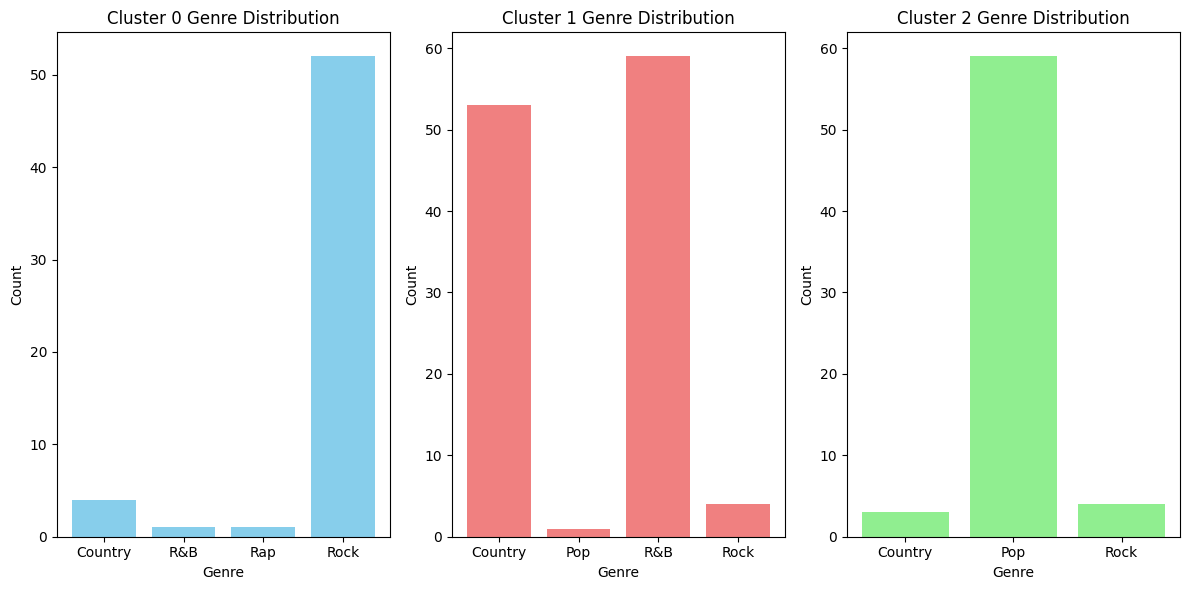

In [13]:
plot_genre_distribution_by_cluster(labels[0], metadata)

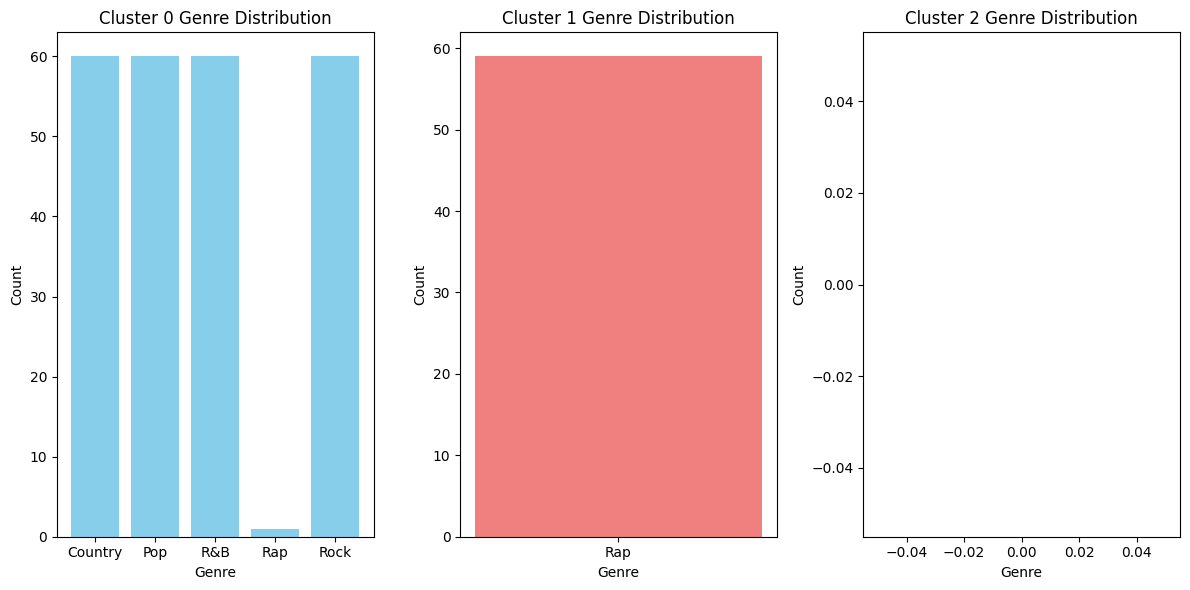

In [14]:
plot_genre_distribution_by_cluster(labels[1], metadata)

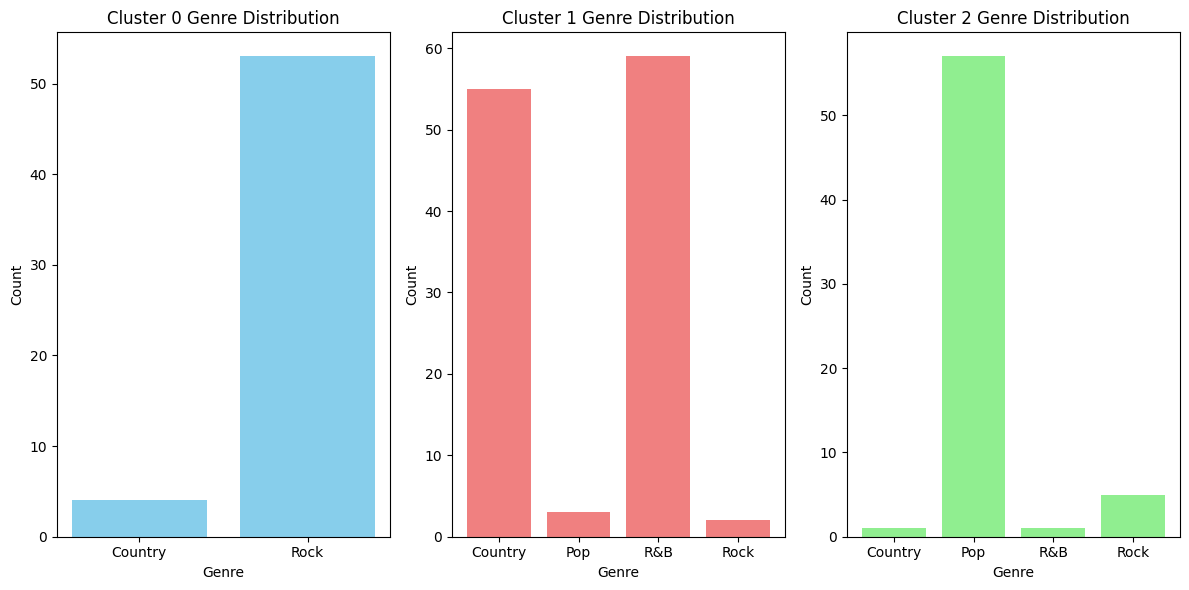

In [15]:
plot_genre_distribution_by_cluster(labels[2], metadata)

ABLATION

In [16]:
scaled_data.head()

,chorus_ratio,syllable_density,sentiment_score,flesch_kincaid_readability,lsa_component_1,lsa_component_2,lsa_component_3
0,1.341589,-0.679807,1.307154,1.481717,-1.251059,-0.690074,1.954008
1,1.514705,-0.826497,1.251919,0.642840,-1.383741,-0.230910,-1.304495
2,-0.079063,-0.867603,0.434716,0.971248,-1.637153,-1.826332,1.848052
3,0.879583,-0.588663,0.218294,0.608648,-1.053347,-1.574317,0.831126
4,0.639872,-0.747759,0.650721,1.620759,-1.124634,-1.484353,1.248035


In [17]:
kA1,best_silhouettesA1,best_daviesbouldinA1,best_aicA,labelsA1 = cluster_with_best_k(scaled_data.drop(["chorus_ratio","syllable_density","flesch_kincaid_readability"], axis=1))
kA2,best_silhouettesA2,best_daviesbouldinA2,best_aicA2,labelsA2 = cluster_with_best_k(scaled_data.drop(["lsa_component_1","lsa_component_2","lsa_component_3","sentiment_score"], axis=1))

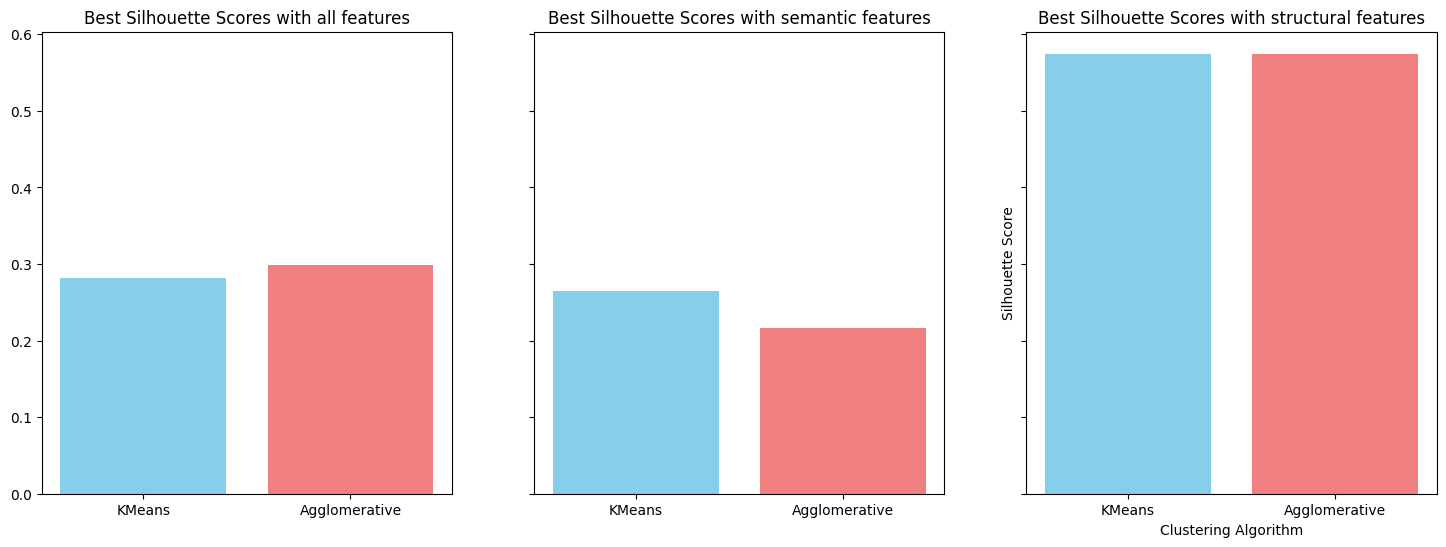

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'Agglomerative'], best_silhouettes[:2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best Silhouette Scores with all features')
barplot = axes[1].bar(['KMeans', 'Agglomerative'], best_silhouettesA1[:2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best Silhouette Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'Agglomerative'], best_silhouettesA2[:2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best Silhouette Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.show()

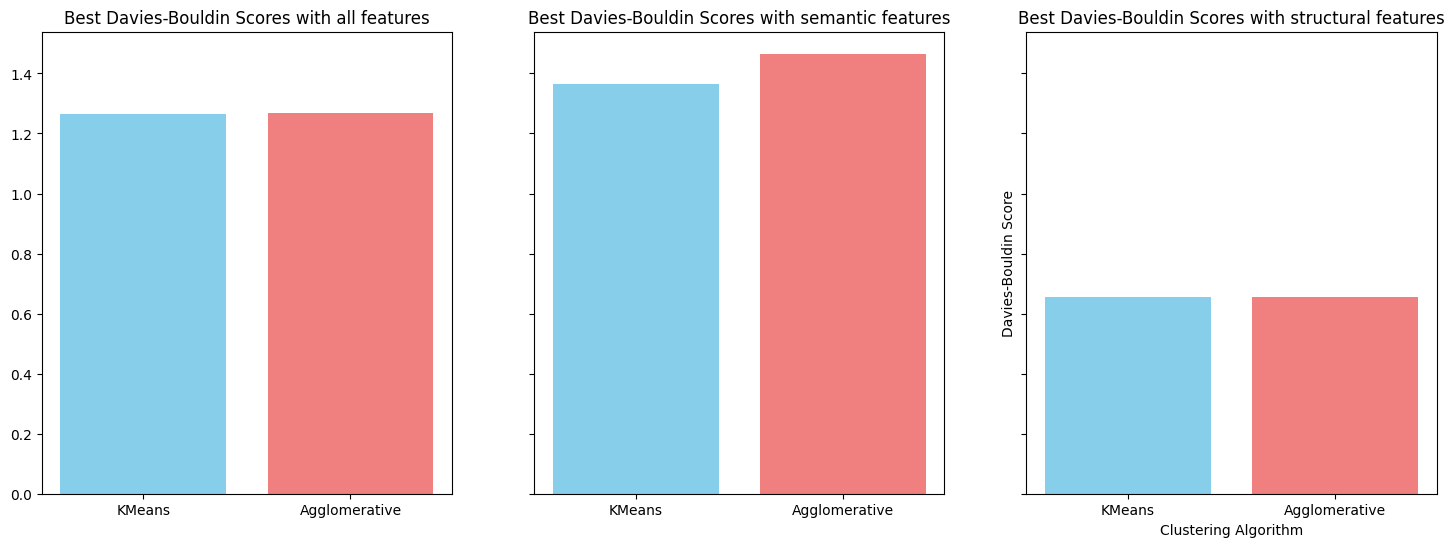

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar(['KMeans', 'Agglomerative'], best_daviesbouldin[:2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best Davies-Bouldin Scores with all features')
barplot = axes[1].bar(['KMeans', 'Agglomerative'], best_daviesbouldinA1[:2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best Davies-Bouldin Scores with semantic features')
barplot = axes[2].bar(['KMeans', 'Agglomerative'], best_daviesbouldinA2[:2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best Davies-Bouldin Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Davies-Bouldin Score')
plt.show()

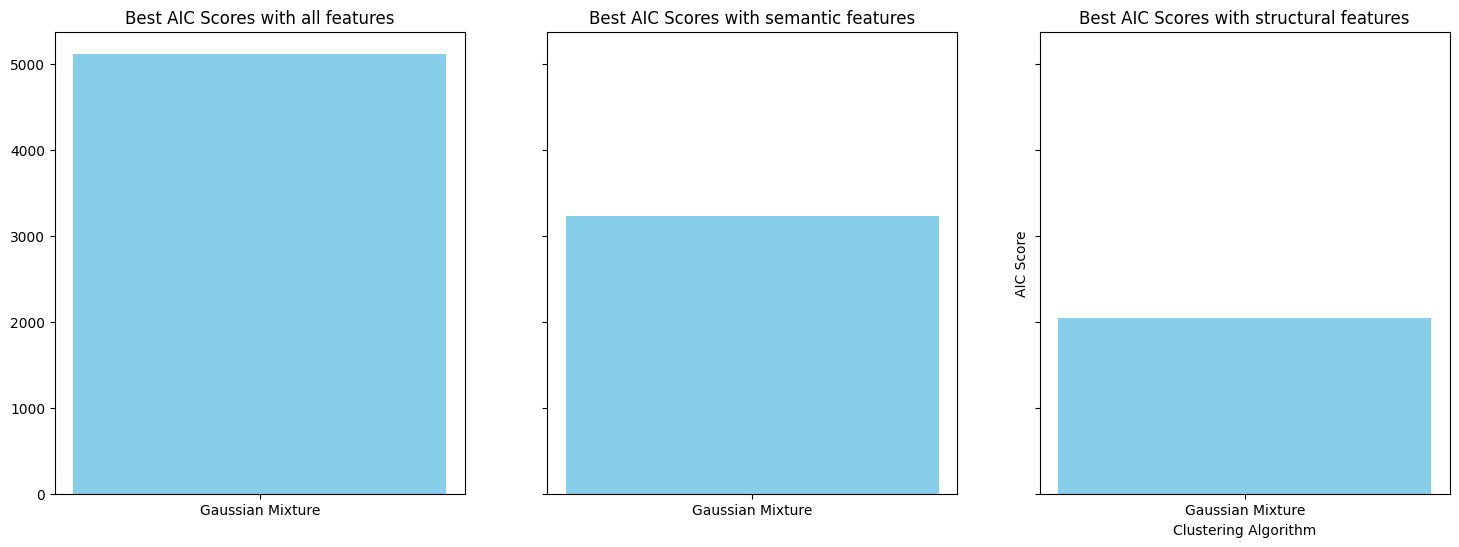

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
barplot = axes[0].bar("Gaussian Mixture", best_aic[2], color=['skyblue', 'lightcoral'])
axes[0].set_title('Best AIC Scores with all features')
barplot = axes[1].bar("Gaussian Mixture", best_aicA[2], color=['skyblue', 'lightcoral'])
axes[1].set_title('Best AIC Scores with semantic features')
barplot = axes[2].bar("Gaussian Mixture", best_aicA2[2], color=['skyblue', 'lightcoral'])
axes[2].set_title('Best AIC Scores with structural features')
plt.xlabel('Clustering Algorithm')
plt.ylabel('AIC Score')
plt.show()